In [25]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [26]:
x = np.linspace(0, 2*np.pi, 100)

def exp_model(x, a, b):
    return a * np.exp(-b * x)

def power_model(x, a, b):
    return a / (x**b)

In [27]:
a_true = 5
b_true = 0.5

y = exp_model(x, a_true, b_true)

sigma = np.linspace(2, 0.2, len(x))
noise = np.random.normal(0, sigma)

y_data = y + noise

In [28]:
exp_params, exp_cov = curve_fit(exp_model, x, y_data)
power_params, power_cov = curve_fit(power_model, x, y_data)

print(f"Exponential model: a = {exp_params[0]:.3f}, b = {exp_params[1]:.3f}")

print(f"Power law model: a = {power_params[0]:.3f}, b = {power_params[1]:.3f}")

Exponential model: a = 5.454, b = 0.600
Power law model: a = 1.000, b = 1.000


C:\Users\samko\AppData\Local\Temp\ipykernel_18280\2936795825.py:7: RuntimeWarning: divide by zero encountered in divide
  return a / (x**b)
C:\Users\samko\AppData\Local\Temp\ipykernel_18280\59707903.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  power_params, power_cov = curve_fit(power_model, x, y_data)


C:\Users\samko\AppData\Local\Temp\ipykernel_18280\2936795825.py:7: RuntimeWarning: divide by zero encountered in divide
  return a / (x**b)


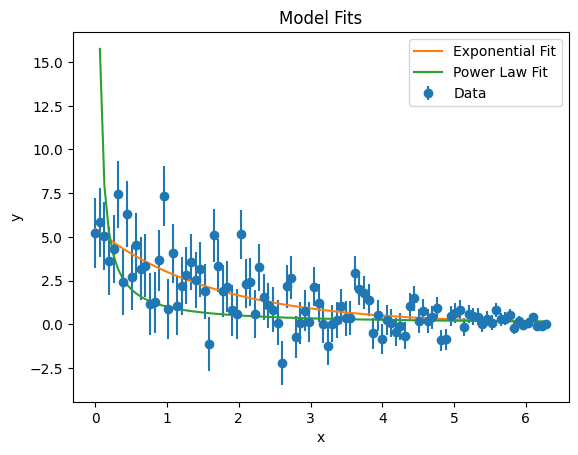

In [29]:
plt.errorbar(x, y_data, yerr=sigma, fmt='o', label='Data')

plt.plot(x, exp_model(x, *exp_params), label='Exponential Fit')
plt.plot(x, power_model(x, *power_params), label='Power Law Fit')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Model Fits")

plt.legend()

plt.savefig("question3.pdf")

plt.show()